# Experimento 1: CLIP solo (imagen)
**Estrategia:** Linear probe — backbone CLIP ViT-L/14 congelado + capa lineal entrenable  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)  
**Referencia:** Asgharnezhad et al. (2025) — CLIP ViT-L/14 + clasificador lineal

## 0. Setup

In [1]:
!pip install open_clip_torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import open_clip

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Configuración de rutas

In [4]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
IMGS_DIR     = os.path.join(BASE_PATH, 'images')
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')
os.makedirs(RESULTS_PATH, exist_ok=True)

img_index = {}
for part in ['imgs_part_1', 'imgs_part_2', 'imgs_part_3']:
    part_path = os.path.join(IMGS_DIR, part)
    for fname in os.listdir(part_path):
        img_index[fname] = os.path.join(part_path, fname)

print(f'Imágenes indexadas: {len(img_index)}')

Imágenes indexadas: 2298


## 2. Cargar splits

In [5]:
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

for df in [df_train, df_val, df_test]:
    df['img_path'] = df['img_id'].map(img_index)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Train — Maligno: {df_train["label"].sum()} | Benigno: {(df_train["label"]==0).sum()}')

Train: 1838 | Val: 230 | Test: 230
Train — Maligno: 871 | Benigno: 967


## 3. Cargar modelo CLIP

In [6]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-L-14', pretrained='openai'
)
clip_model = clip_model.to(device)
clip_model.eval()

for param in clip_model.parameters():
    param.requires_grad = False

print('CLIP ViT-L/14 cargado y congelado')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-L/14 cargado y congelado


## 4. Dataset para extracción de imágenes

In [7]:
class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['img_path']).convert('RGB')
        img   = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label

## 5. Pre-extraer embeddings CLIP (una sola vez)
Los embeddings se guardan en Drive para reutilizarlos en todos los experimentos.

In [8]:
def extract_embeddings(df, clip_model, preprocess, device, batch_size=64):
    dataset    = SkinDataset(df, preprocess)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embeddings, labels = [], []
    clip_model.eval()
    with torch.no_grad():
        for imgs, lbls in tqdm(loader):
            imgs  = imgs.to(device)
            feats = clip_model.encode_image(imgs)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            embeddings.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

# Verificar si ya existen embeddings guardados
clip_train_path = os.path.join(RESULTS_PATH, 'clip_X_train.npy')

if os.path.exists(clip_train_path):
    print('Embeddings ya existen, cargando desde Drive...')
    X_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
    X_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
    X_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))
    y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
    y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
    y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))
else:
    print('Extrayendo embeddings (solo ocurre una vez)...')
    print('Train...')
    X_train, y_train = extract_embeddings(df_train, clip_model, preprocess, device)
    print('Val...')
    X_val,   y_val   = extract_embeddings(df_val,   clip_model, preprocess, device)
    print('Test...')
    X_test,  y_test  = extract_embeddings(df_test,  clip_model, preprocess, device)

    np.save(os.path.join(RESULTS_PATH, 'clip_X_train.npy'), X_train)
    np.save(os.path.join(RESULTS_PATH, 'clip_X_val.npy'),   X_val)
    np.save(os.path.join(RESULTS_PATH, 'clip_X_test.npy'),  X_test)
    np.save(os.path.join(RESULTS_PATH, 'y_train.npy'),      y_train)
    np.save(os.path.join(RESULTS_PATH, 'y_val.npy'),        y_val)
    np.save(os.path.join(RESULTS_PATH, 'y_test.npy'),       y_test)

print(f' X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

Extrayendo embeddings (solo ocurre una vez)...
Train...


  0%|          | 0/29 [00:00<?, ?it/s]

Val...


  0%|          | 0/4 [00:00<?, ?it/s]

Test...


  0%|          | 0/4 [00:00<?, ?it/s]

 X_train: (1838, 768) | X_val: (230, 768) | X_test: (230, 768)


## 6. DataLoaders sobre embeddings (sin imágenes)

In [9]:
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_v  = torch.tensor(X_val,   dtype=torch.float32)
y_v  = torch.tensor(y_val,   dtype=torch.float32)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=64, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 29 | Val: 4 | Test: 4


## 7. Cabeza lineal entrenable

In [10]:
head = nn.Sequential(
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1)
).to(device)

trainable = sum(p.numel() for p in head.parameters())
print(f'Parámetros entrenables: {trainable:,}')

Parámetros entrenables: 197,121


## 8. Entrenamiento (rápido — solo sobre embeddings)

In [11]:
EPOCHS    = 30
LR        = 1e-3
THRESHOLD = 0.5
PATIENCE  = 10

criterion       = nn.BCEWithLogitsLoss()
optimizer       = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=1e-4)
scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_auc    = 0
patience_count  = 0
best_model_path = os.path.join(RESULTS_PATH, 'clip_solo_head.pt')
history         = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    # Entrenamiento
    head.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(head(X_b).squeeze(1), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validación
    head.eval()
    val_loss, val_probs, val_labels = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = head(X_b).squeeze(1)
            val_loss += criterion(out, y_b).item()
            val_probs.extend(torch.sigmoid(out).cpu().numpy())
            val_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(head.state_dict(), best_model_path)
        patience_count = 0
        print(f' Mejor modelo guardado (AUC={best_val_auc:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping en epoch {epoch+1}')
            break

print(f'\nMejor Val AUC: {best_val_auc:.4f}')

Epoch 01 | Train Loss: 0.6548 | Val Loss: 0.6028 | Val AUC: 0.8558
 Mejor modelo guardado (AUC=0.8558)
Epoch 02 | Train Loss: 0.5420 | Val Loss: 0.4956 | Val AUC: 0.8690
 Mejor modelo guardado (AUC=0.8690)
Epoch 03 | Train Loss: 0.4717 | Val Loss: 0.4518 | Val AUC: 0.8849
 Mejor modelo guardado (AUC=0.8849)
Epoch 04 | Train Loss: 0.4402 | Val Loss: 0.4270 | Val AUC: 0.8966
 Mejor modelo guardado (AUC=0.8966)
Epoch 05 | Train Loss: 0.4200 | Val Loss: 0.4158 | Val AUC: 0.9011
 Mejor modelo guardado (AUC=0.9011)
Epoch 06 | Train Loss: 0.4027 | Val Loss: 0.4083 | Val AUC: 0.9050
 Mejor modelo guardado (AUC=0.9050)
Epoch 07 | Train Loss: 0.3938 | Val Loss: 0.3997 | Val AUC: 0.9074
 Mejor modelo guardado (AUC=0.9074)
Epoch 08 | Train Loss: 0.3790 | Val Loss: 0.3964 | Val AUC: 0.9092
 Mejor modelo guardado (AUC=0.9092)
Epoch 09 | Train Loss: 0.3748 | Val Loss: 0.3916 | Val AUC: 0.9093
 Mejor modelo guardado (AUC=0.9093)
Epoch 10 | Train Loss: 0.3676 | Val Loss: 0.3861 | Val AUC: 0.9117
 Mejor

## 9. Curvas de entrenamiento

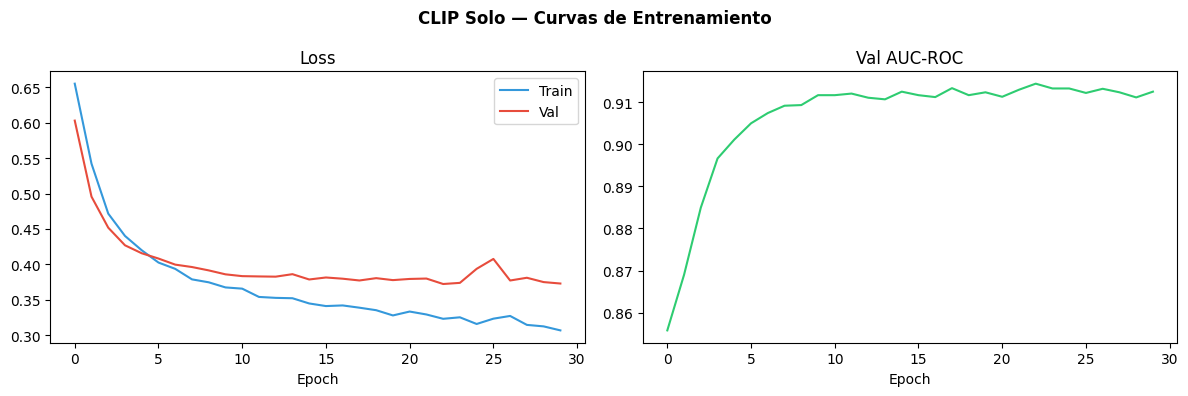

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_auc'], color='#2ecc71')
axes[1].set_title('Val AUC-ROC')
axes[1].set_xlabel('Epoch')

plt.suptitle('CLIP Solo — Curvas de Entrenamiento', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_solo_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluación en Test

In [13]:
head.load_state_dict(torch.load(best_model_path))
head.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = head(X_b.to(device)).squeeze(1)
        test_probs.extend(torch.sigmoid(out).cpu().numpy())
        test_labels.extend(y_b.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= THRESHOLD).astype(int)

auc       = roc_auc_score(test_labels, test_probs)
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print('=' * 50)
print('  RESULTADOS — CLIP SOLO (imagen)')
print('=' * 50)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {accuracy*100:.1f}%')
print(f'  Precision : {precision*100:.1f}%')
print(f'  Recall    : {recall*100:.1f}%')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(test_labels, test_preds, target_names=['Benigno', 'Maligno']))

  RESULTADOS — CLIP SOLO (imagen)
  AUC-ROC   : 0.9048
  Accuracy  : 82.2%
  Precision : 80.5%
  Recall    : 82.7%
  F1-Score  : 0.8161

              precision    recall  f1-score   support

     Benigno       0.84      0.82      0.83       120
     Maligno       0.81      0.83      0.82       110

    accuracy                           0.82       230
   macro avg       0.82      0.82      0.82       230
weighted avg       0.82      0.82      0.82       230



## 11. Matriz de confusión

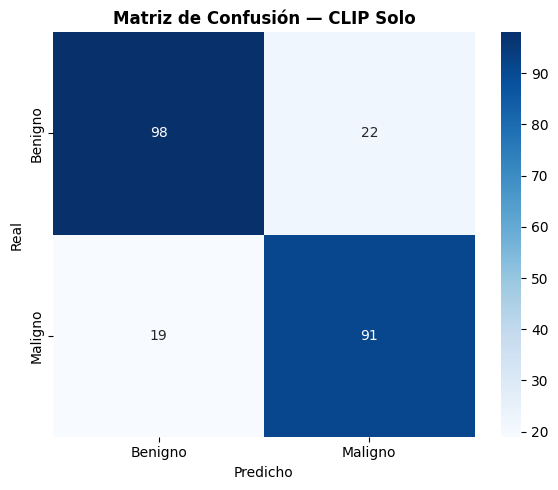

In [14]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax)
ax.set_title('Matriz de Confusión — CLIP Solo', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_solo_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Guardar resultados

In [15]:
results = {
    'modelo':    'CLIP solo (imagen)',
    'backbone':  'ViT-L/14 OpenAI',
    'auc':       round(auc, 4),
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
}

results_path = os.path.join(RESULTS_PATH, 'resultados_clip_solo.csv')
pd.DataFrame([results]).to_csv(results_path, index=False)
print(f'Resultados guardados en: {results_path}')
print(pd.DataFrame([results]))

Resultados guardados en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/resultados_clip_solo.csv
               modelo         backbone     auc  accuracy  precision  recall  \
0  CLIP solo (imagen)  ViT-L/14 OpenAI  0.9048    0.8217     0.8053  0.8273   

       f1  
0  0.8161  
